# Newton Fractals in the Complex Plane

For a polynomial $p(z)$, Newton's method iterates
$$
z_{k+1} = z_k - \frac{p(z_k)}{p'(z_k)}.
$$
Each initial point converges to a root (when it converges), and the basin partition creates a fractal boundary.
This notebook visualizes both the attraction basins and convergence speed.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/newton-fractals-complex/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/newton-fractals-complex") if Path("python/newton-fractals-complex").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Newton Fractals in the Complex Plane**, with equations and plots designed to expose both the model and the numerical behavior.


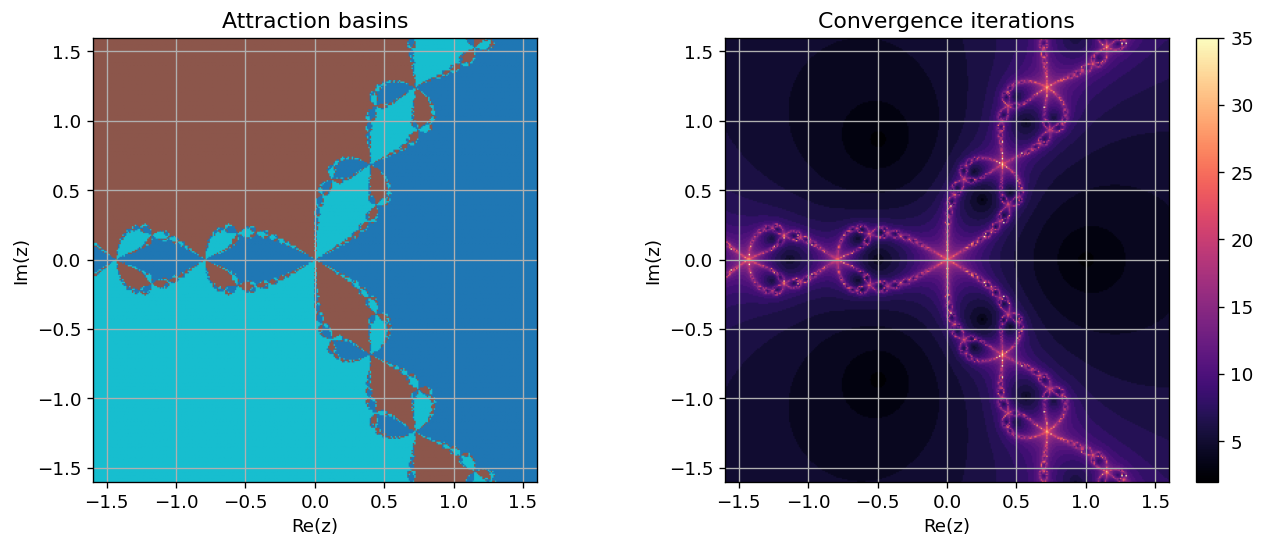

In [2]:
roots = np.array([1.0, np.exp(2j*np.pi/3), np.exp(4j*np.pi/3)])

def p(z):
    return z**3 - 1

def dp(z):
    return 3*z**2

n = 320
x = np.linspace(-1.6, 1.6, n)
y = np.linspace(-1.6, 1.6, n)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

max_iter = 35
tol = 1e-5
idx = np.zeros(Z.shape, dtype=int)
it_count = np.zeros(Z.shape, dtype=int)
W = Z.copy()

for k in range(max_iter):
    W = W - p(W) / (dp(W) + 1e-12)
    d = np.abs(W[..., None] - roots[None, None, :])
    nearest = np.argmin(d, axis=2)
    done = np.min(d, axis=2) < tol
    just_done = (it_count == 0) & done
    it_count[just_done] = k + 1
    idx = nearest

it_count[it_count == 0] = max_iter

fig, axes = plt.subplots(1, 2, figsize=(11, 4.7))
axes[0].imshow(idx, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()], cmap="tab10")
axes[0].set_title("Attraction basins")
axes[0].set_xlabel("Re(z)")
axes[0].set_ylabel("Im(z)")

im = axes[1].imshow(it_count, origin="lower", extent=[x.min(), x.max(), y.min(), y.max()], cmap="magma")
axes[1].set_title("Convergence iterations")
axes[1].set_xlabel("Re(z)")
axes[1].set_ylabel("Im(z)")
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- J. Milnor, *Dynamics in One Complex Variable*, Princeton Univ. Press, 2006.
- H.-O. Peitgen, P. H. Richter, *The Beauty of Fractals*, Springer, 1986.
- L. V. Ahlfors, *Complex Analysis*, McGraw-Hill, 1979.
